/tmp/ipython-input-4207383348.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, end=end)
[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 100)        │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 60, 100)        │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 50)             │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151,451 (591.61 KB)

 Trainable params: 151,451 (591.61 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 10s 258ms/step - loss: 0.0738 - val_loss: 0.0151
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 216ms/step - loss: 0.0050 - val_loss: 0.0160
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 325ms/step - loss: 0.0033 - val_loss: 0.0065
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 222ms/step - loss: 0.0023 - val_loss: 0.0024
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 219ms/step - loss: 0.0017 - val_loss: 0.0014
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 230ms/step - loss: 0.0015 - val_loss: 0.0015
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 221ms/step - loss: 0.0014 - val_loss: 9.9221e-04
Epoch 8/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 218ms/step - loss: 0.0013 - val_loss: 0.0011
Epoch 9/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 226ms/step - loss: 0.0013 - val_loss: 9.7360e-04
Epoch 10/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 225ms/step - loss: 0.0013 - val_loss: 0.0018
Epoch 11/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 216ms/step - loss: 0.0014 - val_loss: 9.4197e-04
Epoch 12/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 

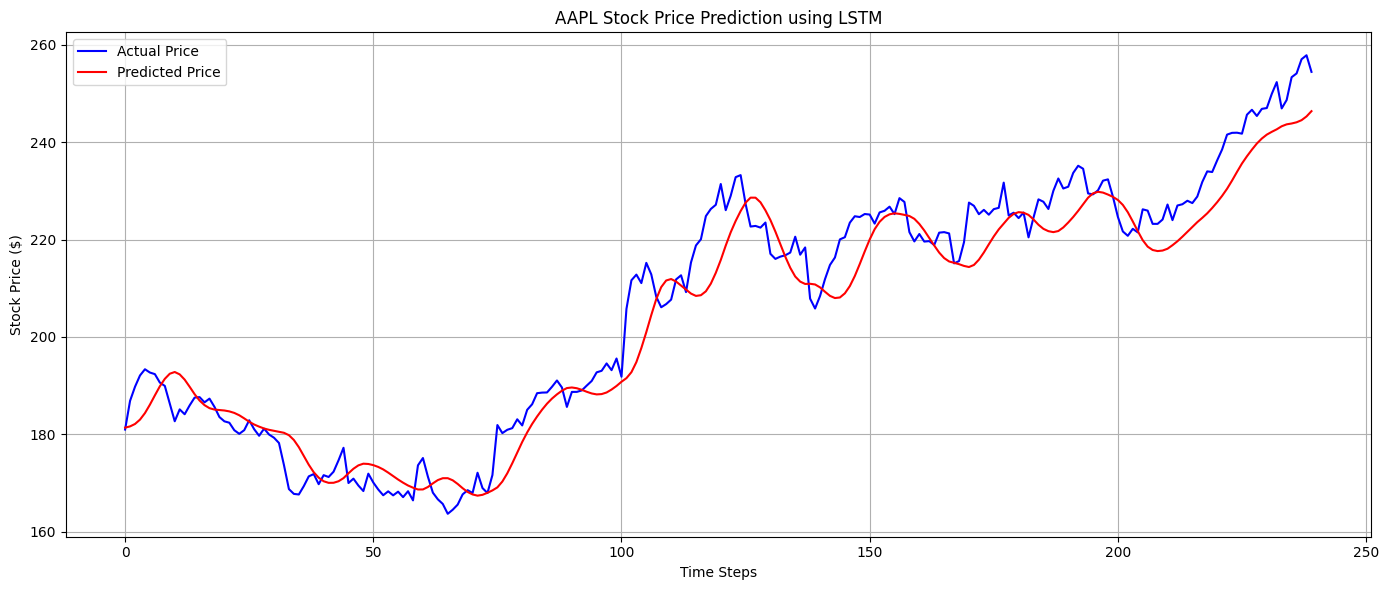

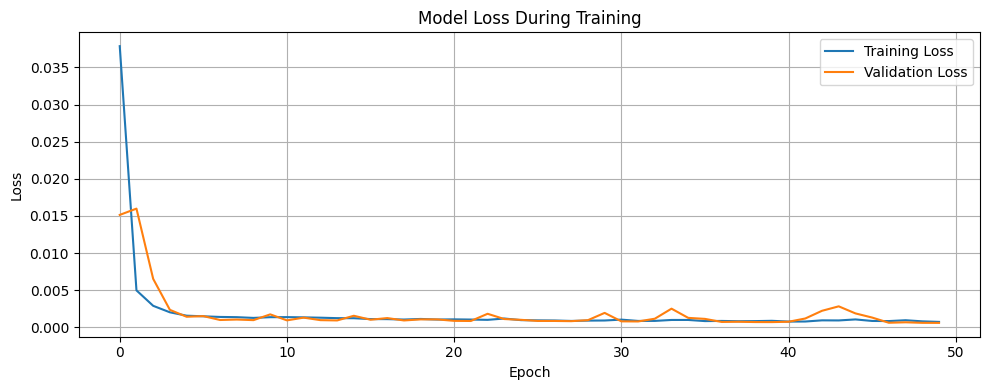

In [2]:
# 📦 Step 1: Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import math

# 📥 Step 2: Load and Prepare Dataset
def load_data(ticker='AAPL', start='2020-01-01', end='2024-12-31'):
    df = yf.download(ticker, start=start, end=end)
    if df.empty:
        raise ValueError("No data fetched. Check ticker or date range.")
    return df[['Close']]

# 🔄 Step 3: Normalize and Create Time Series
def preprocess_data(data, time_step=60):
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(data)

    X, Y = [], []
    for i in range(len(scaled_data) - time_step - 1):
        X.append(scaled_data[i:(i + time_step), 0])
        Y.append(scaled_data[i + time_step, 0])

    X = np.array(X).reshape(-1, time_step, 1)
    Y = np.array(Y)
    return X, Y, scaler

# 🧠 Step 4: Build LSTM Model
def build_model(input_shape):
    model = Sequential([
        LSTM(100, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(100, return_sequences=True),
        Dropout(0.2),
        LSTM(50),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# 📊 Step 5: Plot Predictions
def plot_predictions(actual, predicted, title='Stock Price Prediction'):
    plt.figure(figsize=(14, 6))
    plt.plot(actual, label='Actual Price', color='blue')
    plt.plot(predicted, label='Predicted Price', color='red')
    plt.title(title)
    plt.xlabel('Time Steps')
    plt.ylabel('Stock Price ($)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# 📉 Step 6: Plot Training Loss
def plot_training_loss(history):
    plt.figure(figsize=(10, 4))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss During Training')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# 🚀 Main Execution
if __name__ == "__main__":
    # Load and preprocess data
    df = load_data()
    data = df.values
    time_step = 60
    X, y, scaler = preprocess_data(data, time_step)

    # Train-test split
    train_size = int(len(X) * 0.8)
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]

    # Build and train model
    model = build_model((X_train.shape[1], 1))
    model.summary()
    history = model.fit(X_train, y_train, epochs=50, batch_size=64, validation_split=0.1, verbose=1)

    # Predict and inverse transform
    train_pred = scaler.inverse_transform(model.predict(X_train))
    test_pred = scaler.inverse_transform(model.predict(X_test))
    y_train_scaled = scaler.inverse_transform(y_train.reshape(-1, 1))
    y_test_scaled = scaler.inverse_transform(y_test.reshape(-1, 1))

    # Evaluate
    train_rmse = math.sqrt(mean_squared_error(y_train_scaled, train_pred))
    test_rmse = math.sqrt(mean_squared_error(y_test_scaled, test_pred))
    print(f"✅ Train RMSE: {train_rmse:.2f}")
    print(f"✅ Test RMSE: {test_rmse:.2f}")

    # Visualize
    plot_predictions(y_test_scaled, test_pred, title='AAPL Stock Price Prediction using LSTM')
    plot_training_loss(history)